# Welcome to ProtoX-AD 🚀

This notebook is a friendly introduction to using ProtoX-AD for time series anomaly detection and characterization. Here, you will learn step by step how to:

📂 Load your data

⚙️ Set the transformations considered in the transformation module

⚡ Launch experiments and evaluate anomaly detection performance

🔎 Inspect the learned prototypes to characterize different types of anomalies

The goal is to give you a quick and practical walkthrough so you can easily apply ProtoX-AD to any dataset.

👉 It's very simple, so let's get started!

# Load Resources
The code required to use ProtoX-AD can be imported from the following modules and scripts:

In [1]:
from models import *
from datasets import *
from utils import *
from transformations import *

# Load Data 
For the experiments, we will use datasets from the UCR Time Series Classification Archive. Data loading is handled with the aeon library through a helper function we provide, called `get_dataset()`.

When loading a dataset, you will need to specify:

* `dataset`: the name of the dataset to load

* `normal`: which class is considered the normal one

* `reverse`: defines how anomalies are assigned. Two possible values:

    * False: the class defined in normal is treated as normal, and all others are anomalies

    * True: all classes except the one defined in normal are treated as normal, and that class is considered anomalous

The function `get_dataset()` returns:

* `dataset`: name of the dataset loaded

* `train_data`: training samples (only from the normal class)

* `test_data`: test samples (all classes included)

* `test_labels`: binary labels for evaluation (1 = normal, 0 = anomalous)

* `real_labels`: the original class names of the test samples

Additionally, the function also prints information about the existing classes in the dataset, clearly indicating which ones have been defined as normal and which as abnormal.

## The UMD dataset

In this tutorial, we will work with the **UMD dataset**, a benchmark dataset for time series anomaly detection. Before applying ProtoX-AD, we will first take a look at the data and briefly describe the different classes considered in this example.

In [2]:
dataset, train_data, test_data, test_labels, real_labels  = get_dataset(dataset="UMD", normal="2", reverse=False)

Problem name:  umd
Existing Classes:  ['1', '2', '3']
Normal Class(es):  ['2']
Anomalous Class(es):  ['1' '3']


The UMD dataset contains synthetic time series with a common baseline structure based on a central plateau. Normal samples follow this baseline pattern without additional events. Anomalous samples, instead, include a bell-shaped event that can point upward or downward and may appear either near the beginning or near the end of the series. In some cases, the central plateau is also inverted.

This makes UMD a simple but useful example for understanding how ProtoX-AD detects anomalies and how the learned prototypes can reveal different types of anomalous behavior. The examples below illustrate these patterns: the blue series corresponds to a normal sample, while the red series show different anomalous variants with upward or downward bumps, located either at the beginning or at the end of the sequence.

![alt text](Figures/UMD_examples.png "Title")

# ProtoX-AD

For the UMD dataset, we define manual transformations that mimic the anomaly patterns present in the data. Since anomalous samples are characterized by bell-shaped events, the transformations should generate augmented views by adding either upward or downward bumps to normal training samples.

We consider the identity transformation plus eight anomaly-inspired transformations. These are obtained by combining:

- the **bump direction**: upward or downward,
- the **bump position**: near the beginning or near the end of the sequence,
- the **central plateau orientation**: preserved or inverted.

This results in nine transformations in total. To introduce variability, some transformation parameters are randomly sampled at each call, such as the bump amplitude, a small jitter near the sequence edge, and a temporal shift towards the center. This allows the generated views to preserve the general anomaly structure while avoiding always producing exactly the same pattern.


### Visualizing the manual transformations

Before training ProtoX-AD, let's inspect the augmented views generated by the manual transformation module. This helps us verify that the transformations encode the anomaly patterns we want the model to learn.

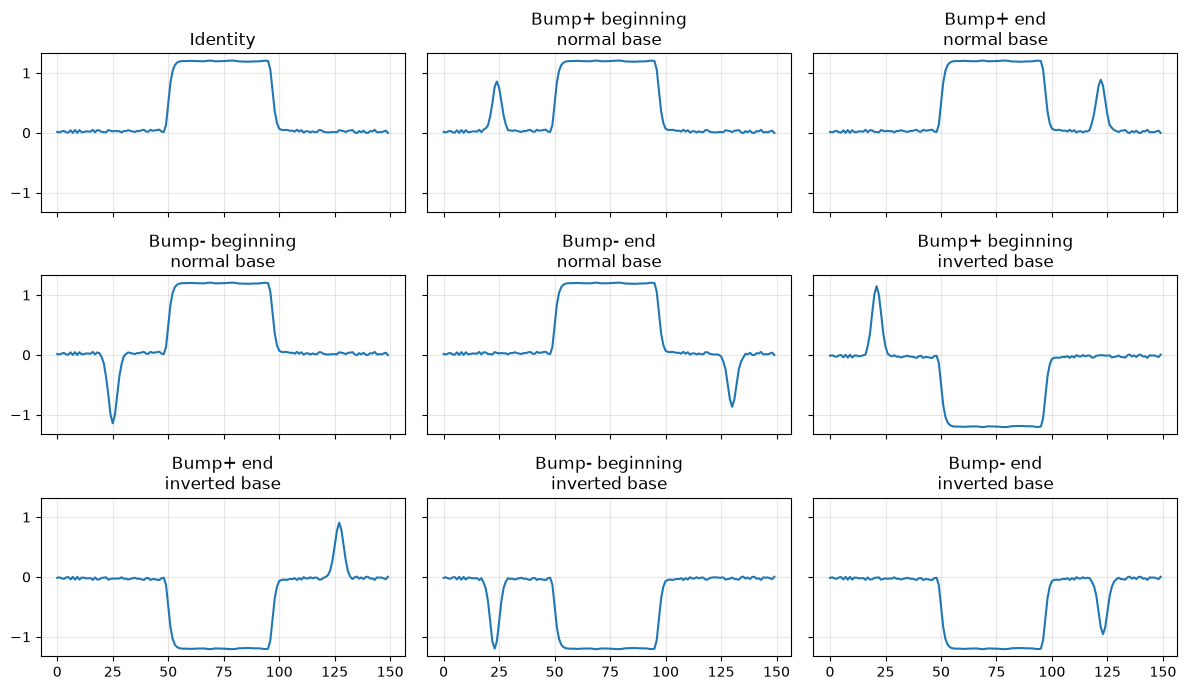

In [3]:
from transformations import UMDTransformations

# Select one normal training sample
sample = torch.Tensor(train_data[0]).unsqueeze(0)

# Ensure shape is (B, T, F)
if not torch.is_tensor(sample):
    sample = torch.tensor(sample, dtype=torch.float32)

if sample.ndim == 1:
    sample = sample[None, :, None]      # (1, T, 1)
elif sample.ndim == 2:
    sample = sample[None, :, :]         # (1, T, F)

# Instantiate the manual transformation module
transformations = UMDTransformations(
    bump_width=6,
    bump_amplitude=1.0,
    bump_random_shift=5,
    bump_random_scale=0,
    width_random_scale=0,
    inward_shift_range=(15, 20),
    mask_power=1.0,
)

# Generate the 9 augmented views
views = transformations.generate(sample, n_repeats=1)  # (9, T, F)

view_names = [
    "Identity",
    "Bump+ beginning\nnormal base",
    "Bump+ end\nnormal base",
    "Bump- beginning\nnormal base",
    "Bump- end\nnormal base",
    "Bump+ beginning\ninverted base",
    "Bump+ end\ninverted base",
    "Bump- beginning\ninverted base",
    "Bump- end\ninverted base",
]

# Plot views
fig, axes = plt.subplots(3, 3, figsize=(12, 7), sharex=True, sharey=True)

for ax, view, title in zip(axes.ravel(), views, view_names):
    ax.plot(view[:, 0].detach().cpu().numpy())
    ax.set_title(title)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Instantiate and train and evaluate ProtoX-AD

The next step is to instantiate the ProtoX-AD model, train it on the normal data, and finally evaluate its performance on the test set.

The `ProtoXAD` object requires the following hyperparameters when being instantiated:

- `seq_len`: length of the input time series.
- `latent_dims`: dimensionality of the latent representation learned by the encoder.
- `input_dims`: number of features in the original time series.
- `train_data`: normal samples used for training.
- `val_data`: normal samples used for validation.
- `test_data`: data used for evaluation, including both normal and anomalous samples.
- `n_transforms`: number of transformations generated by the transformation module.
- `transformations`: transformation module used to generate augmented views.
- `num_prototypes_per_class`: number of prototypes learned for each transformation class.


In [6]:
device =  torch.device("mps")

seq_len, input_dims = train_data[0].shape

train_dataset = SelfDataset(train_data)
test_dataset = SelfDataset(test_data)

transformations = UMDTransformations()
n_transforms = 9

num_prototypes_per_class = 3

model = ProtoXAD(input_dims = input_dims, latent_dims = 320, seq_len = seq_len, n_transforms = n_transforms, 
                   train_data = train_dataset, val_data = train_dataset, test_data = test_dataset, 
                   transformations = transformations, num_prototypes_per_class = num_prototypes_per_class).to(device)

In [7]:
model.train()
model.train_model(max_epochs=1000, verbose=True)

Epoch #0: loss=1638.9869689941406, val_loss=38.24180539449056
Epoch #5: loss=97.8121109008789, val_loss=14.611219644546509
Epoch #10: loss=38.98209190368652, val_loss=8.940616607666016
Epoch #15: loss=28.813647270202637, val_loss=7.224281112353007
Epoch #20: loss=24.394789695739746, val_loss=6.3114824295043945
Epoch #25: loss=21.81624698638916, val_loss=5.455347220102946
Epoch #30: loss=19.39203643798828, val_loss=5.152841369311015
Epoch #35: loss=18.155943870544434, val_loss=4.936810334523519
Epoch #40: loss=17.198662281036377, val_loss=4.760640501976013
Epoch #45: loss=17.2191801071167, val_loss=4.839353481928508
Epoch #50: loss=16.25187873840332, val_loss=4.638844648996989
Epoch #55: loss=15.455893516540527, val_loss=4.465940634409587
Epoch #60: loss=15.137414455413818, val_loss=4.476152380307515
Epoch #65: loss=14.463792324066162, val_loss=4.370436906814575
Epoch #70: loss=14.504573345184326, val_loss=4.488884687423706
Epoch #75: loss=13.947295188903809, val_loss=4.330742915471395


In [8]:
model.eval()
scores = model.compute_scores()
auroc, aupr = metrics(scores, test_labels)
print(f"   AUROC: {auroc:.4f}")
print(f"   AUPR : {aupr:.4f}")

   AUROC: 1.0000
   AUPR : 1.0000


## Inspecting the Learned Prototypes

After evaluating the anomaly detection performance, we can inspect the prototypes learned by ProtoX-AD.

Each transformation class is associated with a set of prototypes in the latent space. By decoding these prototypes back to the input space, we can visualize the representative patterns that the model has learned for each transformation-induced view.

This step is useful for interpreting the model: instead of only obtaining an anomaly score, we can examine which types of anomalous patterns are captured by the prototypes and relate them to the transformations defined for the UMD dataset.

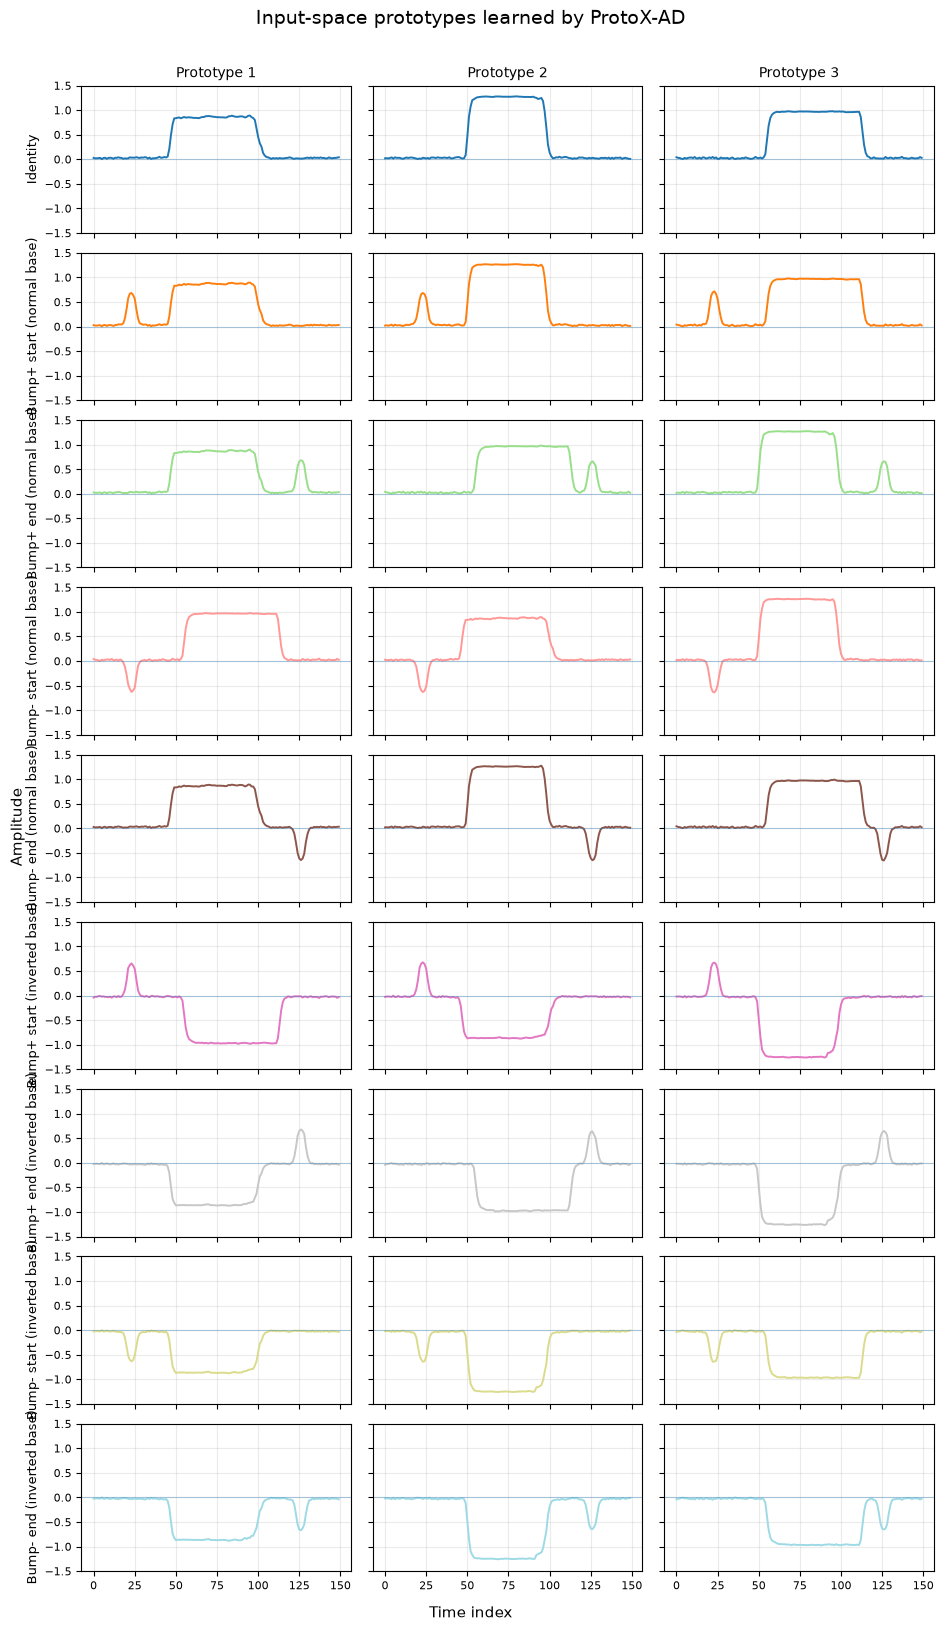

In [16]:
umd_transform_names = [
    "Identity",
    "Bump+ start (normal base)",
    "Bump+ end (normal base)",
    "Bump- start (normal base)",
    "Bump- end (normal base)",
    "Bump+ start (inverted base)",
    "Bump+ end (inverted base)",
    "Bump- start (inverted base)",
    "Bump- end (inverted base)",
]

fig, proto_series = model.plot_prototypes_input(
    transform_names=umd_transform_names,
    ylim=(-1.5, 1.5),
    figsize_per_cell=(3.2, 1.8),
)
plt.show()

### Matching test samples with their nearest prototypes

Once the prototypes have been learned, we can use them to characterize individual test samples. To do this, we first encode each test sample into the latent space and then compute its distance to the learned prototypes.

The nearest prototype provides an interpretable reference pattern for the sample. For example, if a test sample is closest to a prototype associated with a bump transformation, this suggests that the model represents that sample as similar to that transformation-induced anomaly pattern.

---- Distances ----
L1  mean: 0.125501 | std: 0.053317
L2  mean: 0.224765 | std: 0.079981


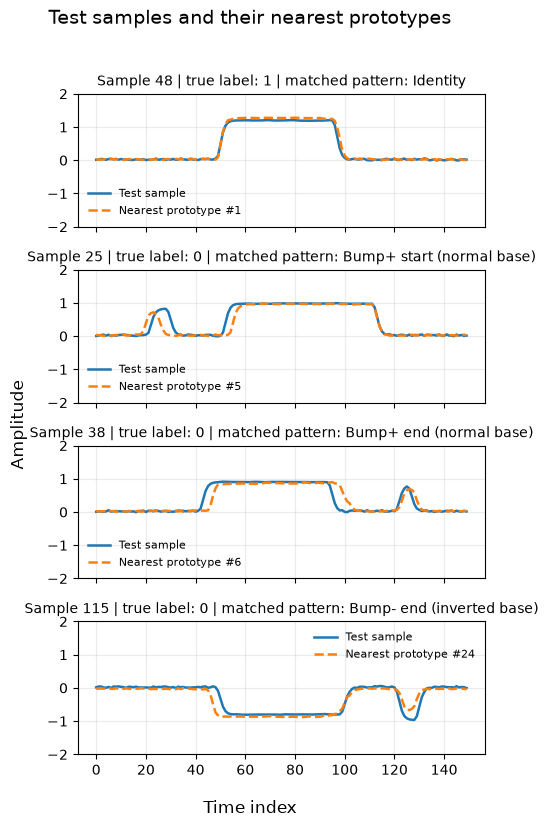

In [18]:
test_loader = DataLoader(SelfDataset(test_data), batch_size=1, shuffle=False)

# 1. Encode test samples into the latent space
mu_test = compute_latents(test_loader, model)

# 2. Find the nearest learned prototype for each sample
nearest_match, nearest_distance = nearest_prototypes_global(mu_test, model)

# Plot a few examples
fig = plot_samples_with_nearest_prototypes(
    samples=test_data,
    nearest_match=nearest_match,
    proto_series=proto_series,
    sample_ids=[48, 25, 38,115],
    labels=test_labels,
    transform_names=umd_transform_names,
    num_prototypes_per_class=model._net.num_prototypes_per_class,
    ylim=(-2, 2),
    figsize=(5, 8),
)


# 3. Compare each sample with its nearest input-space prototype
l1_mean, l2_mean, l1_std, l2_std = compute_distances_to_nearest_prototypes(
    test_loader,
    nearest_match,
    proto_series
)

# ProtoX-AD with Neural Transformations

So far, we have used manual transformations specifically designed for the UMD dataset. However, ProtoX-AD can also be instantiated with **neural transformations**, where the augmented views are generated by trainable neural networks instead of predefined rules.

In this setting, the transformation module consists of multiple convolutional networks. The first view corresponds to the identity transformation, while the remaining views are produced by independent neural transformation networks. These transformations are learned jointly with the rest of the model during training.

This option is useful when we do not want to manually design dataset-specific transformations, or when the relevant anomaly patterns are difficult to encode explicitly.

In [24]:
from transformations import Transformations

# Neural transformation module
neural_transformations = Transformations(
    x_dim=input_dims,
    n_transforms=9,
)

# Instantiate ProtoX-AD with neural transformations
model_neural = ProtoXAD(
    seq_len=seq_len,
    latent_dims=320,
    input_dims=input_dims,
    train_data=train_dataset,
    val_data=train_dataset,
    test_data=test_dataset,
    n_transforms=9,
    transformations=neural_transformations,
    num_prototypes_per_class=num_prototypes_per_class,
)